# Ejercicio 3: Inspección visual de un producto

### Ficha PEAS
| Elemento | Descripción |
| :--- | :--- |
| **P (Performance / Desempeño)** | Tasa de acierto en control de calidad, reducción de falsos positivos y disminución del costo por desperdicio de material. |
| **E (Environment / Entorno)** | Línea de ensamblaje con faja transportadora industrial, estación de iluminación controlada y cámara de visión por computadora. |
| **A (Actuators / Acciones)** | Sistema de desvío neumático / brazo clasificador: emitir "aprobar", "revision manual" o "rechazar". |
| **S (Sensors / Percepciones)** | Matriz NumPy 5x5 binaria capturada por la cámara (0 = píxel normal, 1 = píxel defectuoso). |
| **Objetivo** | Inspeccionar de forma autónoma cada pieza fabricada para asegurar que solo productos conformes avancen a empaque. |

### Justificación de las reglas
Un producto con 0 defectos cumple con los más altos estándares de calidad y pasa de manera automática a la fase de empaque. La detección de entre 1 y 3 píxeles defectuosos (hasta un 12% del área total) representa imperfecciones menores que un operario puede subsanar o reclasificar sin desechar la pieza completa. Si se detectan 4 o más defectos, la falla compromete la integridad funcional o estética de la pieza, justificando su descarte inmediato para mitigar costos por devoluciones o fallas posteriores.

In [5]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    Retorna: (accion, motivo)
    """
    defectos = int(np.sum(imagen == 1))
    
    if defectos == 0:
        return "aprobar", "producto conforme sin defectos detectados"
    elif defectos <= 3:
        return "revision manual", f"anomalia menor: se detectaron {defectos} pixel(es) defectuoso(s)"
    else:
        return "rechazar", f"fallo critico: se detectaron {defectos} pixeles defectuosos"

Caso de Prueba       | Defectos   | Acción             | Motivo
-------------------------------------------------------------------------------------
Sin Defectos         | 0          | aprobar            | producto conforme sin defectos detectados
Defecto Leve (2)     | 2          | revision manual    | anomalia menor: se detectaron 2 pixel(es) defectuoso(s)
Caso Borde (3)       | 3          | revision manual    | anomalia menor: se detectaron 3 pixel(es) defectuoso(s)
Defectuoso (4)       | 4          | rechazar           | fallo critico: se detectaron 4 pixeles defectuosos


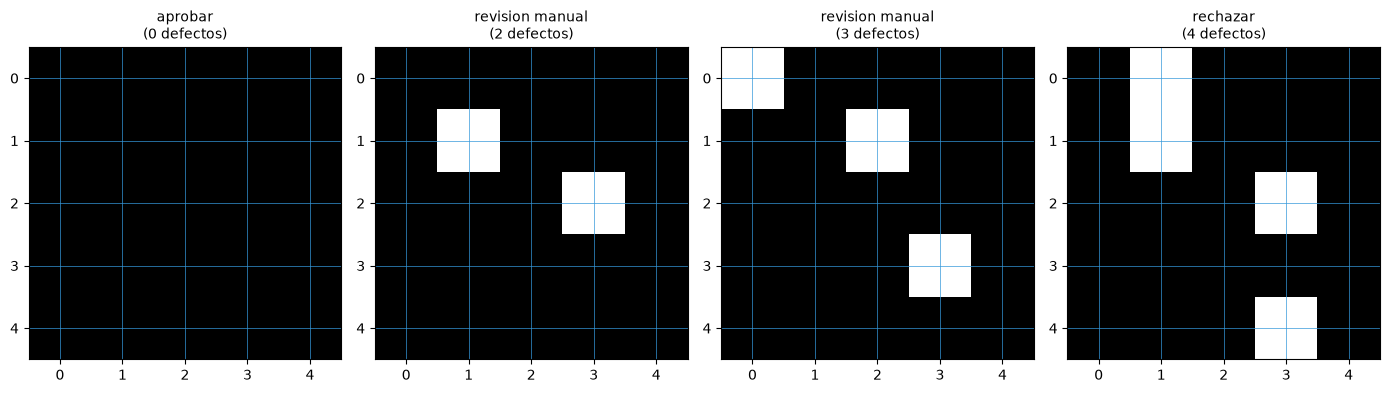

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Caso sin defectos (0) -> Aprobar
img_aprobada = np.zeros((5, 5), dtype=int)

# 2. Caso defecto leve (2 defectos) -> Revisión manual
img_revision = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# 3. Caso borde exacto (3 defectos) -> Revisión manual
img_borde = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0]
])

# 4. Caso superando umbral (4 defectos) -> Rechazar
img_rechazada = np.array([
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0]
])

matrices_prueba = [
    ("Sin Defectos", img_aprobada),
    ("Defecto Leve (2)", img_revision),
    ("Caso Borde (3)", img_borde),
    ("Defectuoso (4)", img_rechazada)
]

print(f"{'Caso de Prueba':<20} | {'Defectos':<10} | {'Acción':<18} | {'Motivo'}")
print("-" * 85)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for idx, (nombre, matriz) in enumerate(matrices_prueba):
    accion, motivo = agente_inspeccion(matriz)
    conteo = int(np.sum(matriz == 1))
    print(f"{nombre:<20} | {conteo:<10} | {accion:<18} | {motivo}")
    
    axes[idx].imshow(matriz, cmap="gray", vmin=0, vmax=1)
    axes[idx].set_title(f"{accion}\n({conteo} defectos)", fontsize=10)
    axes[idx].set_xticks(range(5))
    axes[idx].set_yticks(range(5))
    axes[idx].grid(color='#3498db', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()